In [19]:
import pandas as pd
import numpy as np

# Создаем синтетический датасет: связь часов работы за ПК и усталости глаз
np.random.seed(42)
n = 200

hours_pc = np.round(np.random.uniform(1, 10, n), 1)
# eye_strain = 1.2 * hours_pc + случайный шум (корреляция ~0.85)
eye_strain = np.round(1.2 * hours_pc + np.random.normal(0, 1.5, n), 1)
eye_strain = np.clip(eye_strain, 1, 10)

# sleep_hours: обратная связь с hours_pc
sleep_hours = np.round(8.5 - 0.3 * hours_pc + np.random.normal(0, 0.8, n), 1)
sleep_hours = np.clip(sleep_hours, 4, 10)

# headache_frequency (раз в неделю)
headache = np.round(0.5 * hours_pc + np.random.normal(0, 1.5, n), 0)
headache = np.clip(headache, 0, 7).astype(int)

# screen_breaks (перерывы в час)
breaks = np.round(5 - 0.3 * hours_pc + np.random.normal(0, 1, n), 0)
breaks = np.clip(breaks, 0, 5).astype(int)

# Возраст
age = np.random.randint(18, 45, n)

# Пол
gender = np.random.choice(['male', 'female'], n)

df = pd.DataFrame({
    'age': age,
    'gender': gender,
    'hours_pc': hours_pc,
    'eye_strain': eye_strain,
    'sleep_hours': sleep_hours,
    'headache_per_week': headache,
    'screen_breaks_per_hour': breaks
})

# Сохраняем
df.to_csv('screen_time_health.csv', index=False)

# Проверяем корреляции
print("Корреляции:")
print(df[['hours_pc', 'eye_strain', 'sleep_hours', 'headache_per_week']].corr().round(3))

print(f"\nКорреляция hours_pc vs eye_strain: {df['hours_pc'].corr(df['eye_strain']):.3f}")
print(f"Данные сохранены в screen_time_health.csv")
print(f"Размер: {df.shape}")

Корреляции:
                   hours_pc  eye_strain  sleep_hours  headache_per_week
hours_pc              1.000       0.904       -0.685              0.659
eye_strain            0.904       1.000       -0.634              0.579
sleep_hours          -0.685      -0.634        1.000             -0.385
headache_per_week     0.659       0.579       -0.385              1.000

Корреляция hours_pc vs eye_strain: 0.904
Данные сохранены в screen_time_health.csv
Размер: (200, 7)


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Загрузка данных
df = pd.read_csv('screen_time_health.csv')

print("="*60)
print("screen_time_health")
print("="*60)


screen_time_health


In [21]:
# ============================================
# 1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ
# ============================================

print("\n" + "="*60)
print("1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)

print(f"\nКоличество наблюдений (строк): {df.shape[0]}")
print(f"Количество переменных (столбцов): {df.shape[1]}")

print("\nТипы данных:")
print(df.dtypes)

print("\nПервые 5 строк датасета:")
print(df.head())

print("\nПропущенные значения:")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Количество пропусков': missing_values,
    'Процент пропусков': missing_percent
})
print(missing_df[missing_df['Количество пропусков'] > 0] if missing_values.sum() > 0 else "Пропуски отсутствуют")

print(f"\nОбщее количество пропусков: {df.isnull().sum().sum()}")

# Если есть пропуски - заполняем медианой для числовых и модой для категориальных
if df.isnull().sum().sum() > 0:
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown', inplace=True)
    print("\nПропуски заполнены: числовые - медианой, категориальные - модой")


1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ

Количество наблюдений (строк): 200
Количество переменных (столбцов): 7

Типы данных:
age                         int64
gender                        str
hours_pc                  float64
eye_strain                float64
sleep_hours               float64
headache_per_week           int64
screen_breaks_per_hour      int64
dtype: object

Первые 5 строк датасета:
   age  gender  hours_pc  eye_strain  sleep_hours  headache_per_week  \
0   20    male       4.4         4.3          7.9                  4   
1   34  female       9.6        10.0          5.5                  5   
2   42  female       7.6         9.6          6.2                  4   
3   41  female       6.4         6.6          5.8                  3   
4   29    male       2.4         5.7          7.8                  0   

   screen_breaks_per_hour  
0                       3  
1                       3  
2                       2  
3                       5  
4                       5  

П


2. ОСНОВНЫЕ СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ

Числовые переменные: ['age', 'hours_pc', 'eye_strain', 'sleep_hours', 'headache_per_week', 'screen_breaks_per_hour']

Описательные статистики:
              age    hours_pc  eye_strain  sleep_hours  headache_per_week  \
count  200.000000  200.000000  200.000000   200.000000         200.000000   
mean    31.360000    5.358500    6.297500     6.848500           2.710000   
std      7.495419    2.655842    3.036105     1.100844           1.916839   
min     18.000000    1.000000    1.000000     4.000000           0.000000   
25%     25.000000    3.100000    3.400000     6.100000           1.000000   
50%     31.000000    5.450000    6.400000     6.800000           3.000000   
75%     38.000000    7.800000    9.600000     7.700000           4.000000   
max     44.000000    9.900000   10.000000     9.600000           7.000000   

       screen_breaks_per_hour  
count              200.000000  
mean                 3.510000  
std                  1.

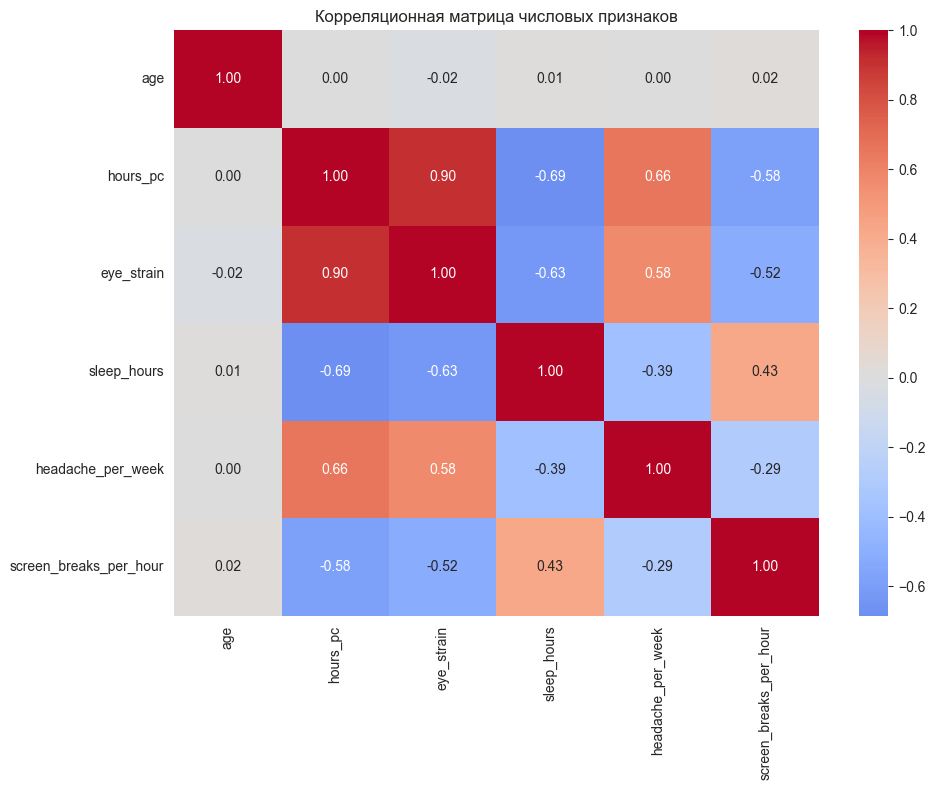

In [22]:
# ============================================
# 2. ОСНОВНЫЕ СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ
# ============================================
print("\n" + "="*60)
print("2. ОСНОВНЫЕ СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ")
print("="*60)

# Числовые переменные
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nЧисловые переменные: {numeric_cols}")

print("\nОписательные статистики:")
print(df[numeric_cols].describe())

print("\nДисперсии числовых признаков:")
print(df[numeric_cols].var())

print("\nКорреляционная матрица:")
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

# Визуализация корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100)
plt.show()


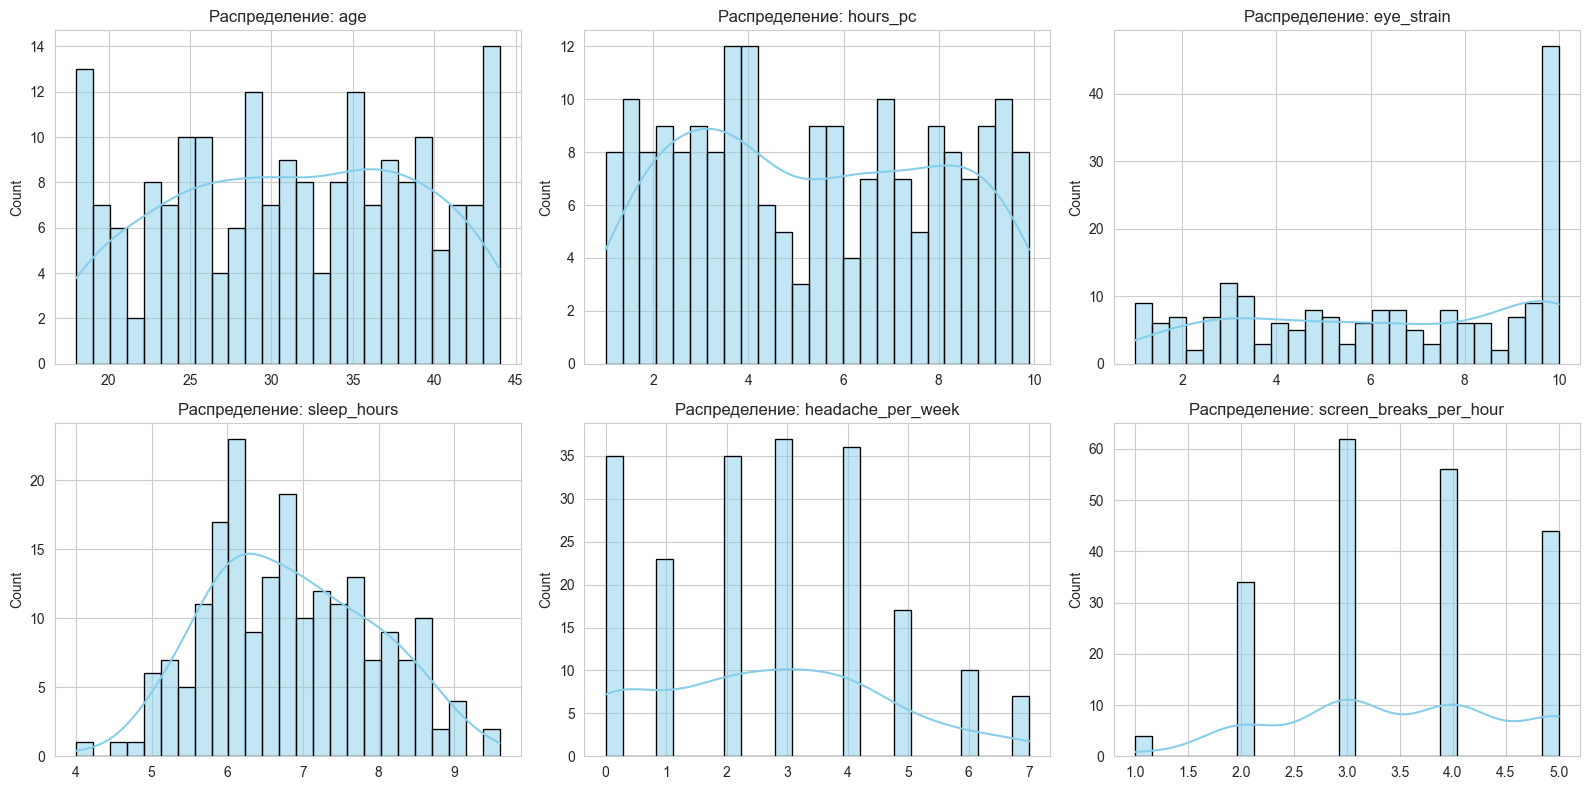

In [23]:
# 3.1 Гистограммы с кривой плотности
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, bins=25, color='skyblue', edgecolor='black')
    ax.set_title(f'Распределение: {col}')
    ax.set_xlabel('')

# Убираем лишние подграфики
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('histograms.png', dpi=100)
plt.show()

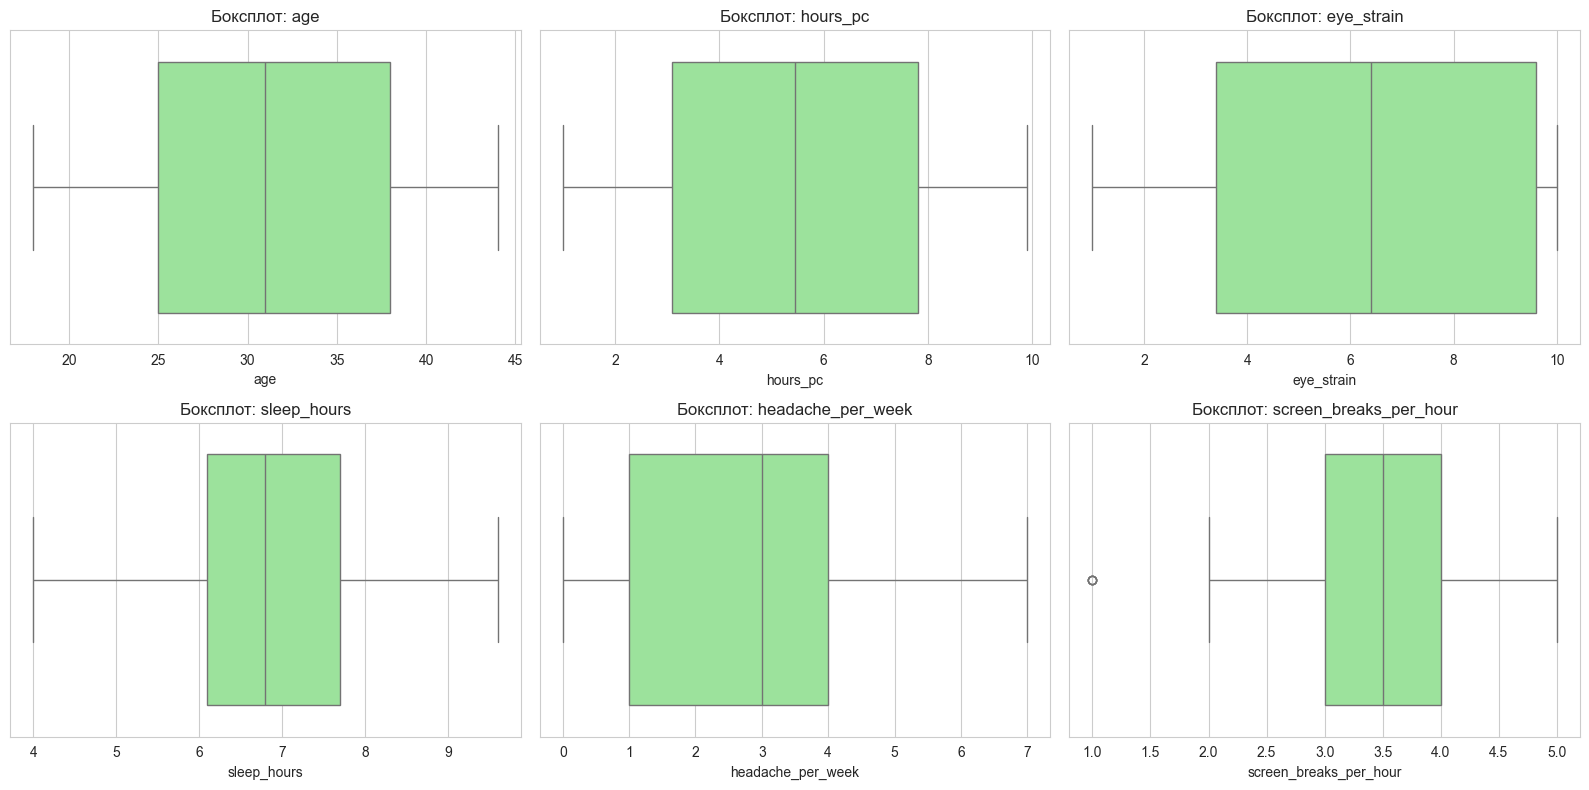

In [24]:
# 3.2 Боксплоты
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(x=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'Боксплот: {col}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('boxplots.png', dpi=100)
plt.show()

Категориальные переменные: ['gender']


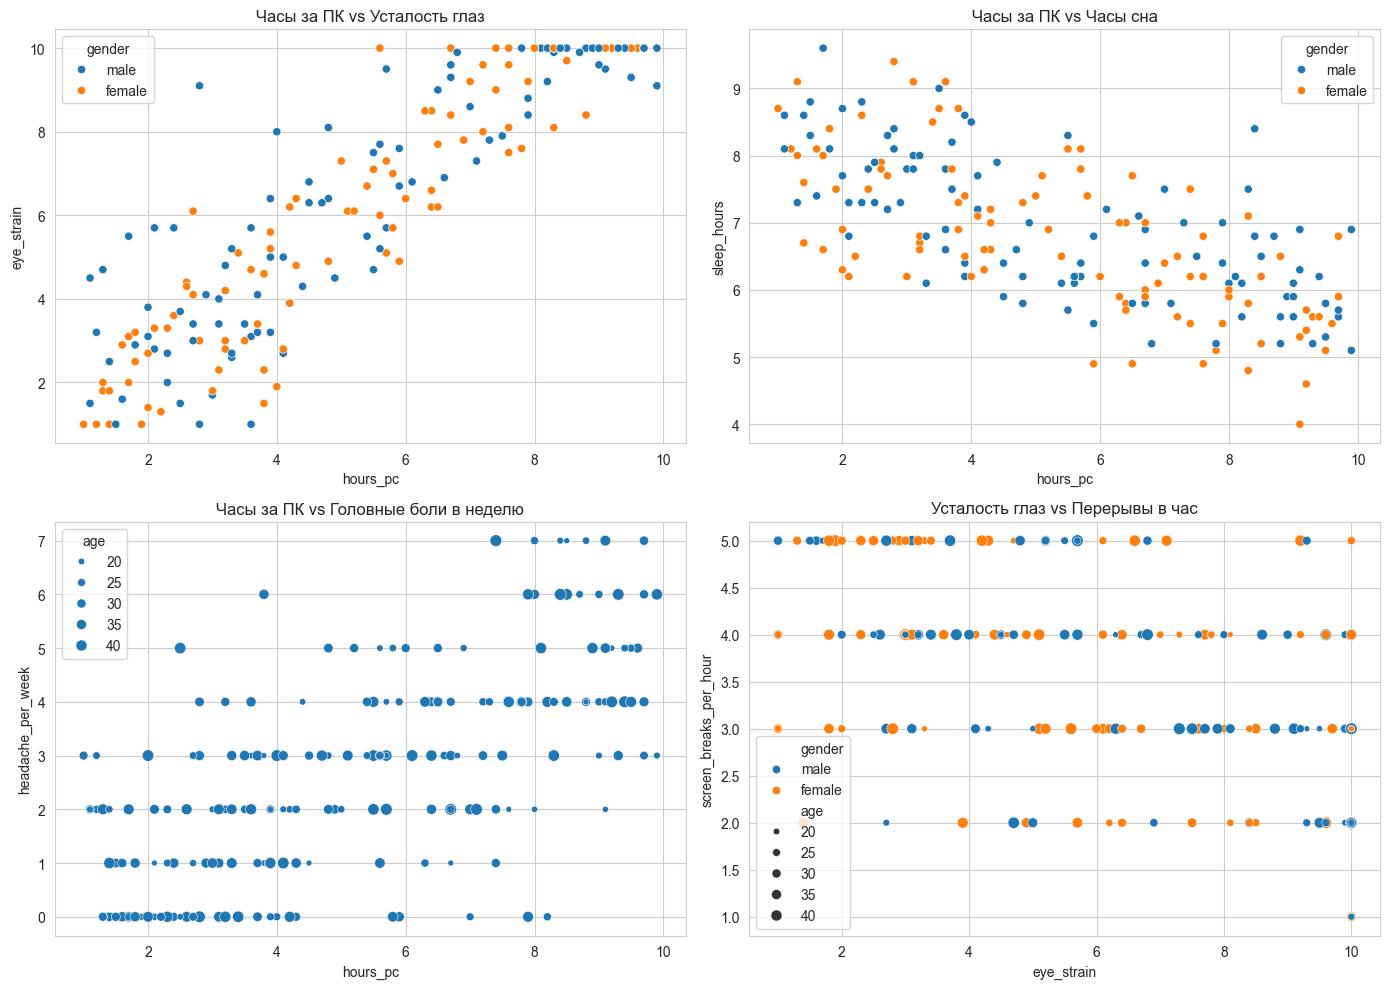

In [26]:
# 3.3 Диаграммы рассеивания
# Определяем категориальные переменные для цветового кодирования
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные переменные: {categorical_cols}")

# Создаем 4 ключевые диаграммы рассеивания
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: hours_pc vs eye_strain (основная зависимость)
sns.scatterplot(data=df, x='hours_pc', y='eye_strain', 
                hue='gender', ax=axes[0,0])
axes[0,0].set_title('Часы за ПК vs Усталость глаз')

# График 2: hours_pc vs sleep_hours
sns.scatterplot(data=df, x='hours_pc', y='sleep_hours', 
                hue='gender', ax=axes[0,1])
axes[0,1].set_title('Часы за ПК vs Часы сна')

# График 3: hours_pc vs headache_per_week
sns.scatterplot(data=df, x='hours_pc', y='headache_per_week', 
                size='age', ax=axes[1,0])
axes[1,0].set_title('Часы за ПК vs Головные боли в неделю')

# График 4: eye_strain vs screen_breaks_per_hour
sns.scatterplot(data=df, x='eye_strain', y='screen_breaks_per_hour', 
                hue='gender', size='age', ax=axes[1,1])
axes[1,1].set_title('Усталость глаз vs Перерывы в час')

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=100)
plt.show()

In [27]:
# ============================================
# 4. ПОИСК ВЫБРОСОВ
# ============================================
print("\n" + "="*60)
print("4. ПОИСК ВЫБРОСОВ (МЕТОД IQR)")
print("="*60)

outliers_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lower_bound': lower_bound, 'upper_bound': upper_bound,
        'outliers_count': len(outliers),
        'outliers_percent': (len(outliers) / len(df)) * 100
    }
    
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Выбросов: {len(outliers)} ({(len(outliers)/len(df))*100:.1f}%)")

# Общее количество строк с выбросами
outlier_mask = pd.Series(False, index=df.index)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask |= (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)

print(f"\nВсего строк с хотя бы одним выбросом: {outlier_mask.sum()} ({outlier_mask.sum()/len(df)*100:.1f}%)")


4. ПОИСК ВЫБРОСОВ (МЕТОД IQR)

age:
  Q1=25.00, Q3=38.00, IQR=13.00
  Границы: [5.50, 57.50]
  Выбросов: 0 (0.0%)

hours_pc:
  Q1=3.10, Q3=7.80, IQR=4.70
  Границы: [-3.95, 14.85]
  Выбросов: 0 (0.0%)

eye_strain:
  Q1=3.40, Q3=9.60, IQR=6.20
  Границы: [-5.90, 18.90]
  Выбросов: 0 (0.0%)

sleep_hours:
  Q1=6.10, Q3=7.70, IQR=1.60
  Границы: [3.70, 10.10]
  Выбросов: 0 (0.0%)

headache_per_week:
  Q1=1.00, Q3=4.00, IQR=3.00
  Границы: [-3.50, 8.50]
  Выбросов: 0 (0.0%)

screen_breaks_per_hour:
  Q1=3.00, Q3=4.00, IQR=1.00
  Границы: [1.50, 5.50]
  Выбросов: 4 (2.0%)

Всего строк с хотя бы одним выбросом: 4 (2.0%)


In [28]:

# ============================================
# 5. ПРОВЕРКА ГИПОТЕЗ
# ============================================
print("\n" + "="*60)
print("5. ПРОВЕРКА СТАТИСТИЧЕСКИХ ГИПОТЕЗ")
print("="*60)

# 5.1 T-тест: сравнение уровня тревожности по полу
if 'gender' in df.columns and 'anxiety_level' in df.columns:
    groups = df.groupby('gender')['anxiety_level'].apply(list).to_dict()
    if len(groups) >= 2:
        group_names = list(groups.keys())
        t_stat, p_val_ttest = stats.ttest_ind(groups[group_names[0]], groups[group_names[1]])
        print(f"\nT-тест: Уровень тревожности ({group_names[0]} vs {group_names[1]}):")
        print(f"  t-статистика = {t_stat:.4f}, p-значение = {p_val_ttest:.4f}")
        if p_val_ttest < 0.05:
            print("  Вывод: Средние статистически значимо различаются (p < 0.05)")
        else:
            print("  Вывод: Нет значимых различий (p >= 0.05)")


5. ПРОВЕРКА СТАТИСТИЧЕСКИХ ГИПОТЕЗ


In [29]:
# ============================================
# 5. ПРОВЕРКА ГИПОТЕЗ
# ============================================
print("\n" + "="*60)
print("5. ПРОВЕРКА СТАТИСТИЧЕСКИХ ГИПОТЕЗ")
print("="*60)

# 5.1 T-тест: сравнение усталости глаз по полу
if 'gender' in df.columns and 'eye_strain' in df.columns:
    groups = df.groupby('gender')['eye_strain'].apply(list).to_dict()
    if len(groups) >= 2:
        group_names = list(groups.keys())
        t_stat, p_val_ttest = stats.ttest_ind(groups[group_names[0]], groups[group_names[1]])
        print(f"\nT-тест: Усталость глаз ({group_names[0]} vs {group_names[1]}):")
        print(f"  t-статистика = {t_stat:.4f}, p-значение = {p_val_ttest:.4f}")
        if p_val_ttest < 0.05:
            print("  Вывод: Средние статистически значимо различаются (p < 0.05)")
        else:
            print("  Вывод: Нет значимых различий (p >= 0.05)")

# 5.2 Тест на нормальность (Шапиро-Уилка) для hours_pc
if 'hours_pc' in df.columns:
    sample_data = df['hours_pc'].dropna()
    if len(sample_data) > 5000:
        sample_data = sample_data.sample(5000, random_state=42)
    
    stat_sw, p_val_sw = stats.shapiro(sample_data)
    print(f"\nТест Шапиро-Уилка (hours_pc):")
    print(f"  Статистика = {stat_sw:.4f}, p-значение = {p_val_sw:.4f}")
    if p_val_sw < 0.05:
        print("  Вывод: Распределение НЕ является нормальным (p < 0.05)")
    else:
        print("  Вывод: Нет оснований отвергать нормальность (p >= 0.05)")

# 5.3 Хи-квадрат тест (gender vs screen_breaks_per_hour)
if 'gender' in df.columns and 'screen_breaks_per_hour' in df.columns:
    contingency_table = pd.crosstab(df['gender'], df['screen_breaks_per_hour'])
    chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"\nХи-квадрат тест (gender vs screen_breaks_per_hour):")
    print(f"  Хи-квадрат = {chi2:.4f}, p-значение = {p_val_chi2:.4f}, df = {dof}")
    if p_val_chi2 < 0.05:
        print("  Вывод: Есть значимая связь между переменными (p < 0.05)")
    else:
        print("  Вывод: Переменные независимы (p >= 0.05)")

# 5.4 ANOVA: eye_strain по возрастным группам
if 'age' in df.columns and 'eye_strain' in df.columns:
    # Создаем возрастные группы
    df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 45], labels=['18-25', '26-35', '36-45'])
    age_groups = df['age_group'].unique()
    groups_data = [df[df['age_group'] == g]['eye_strain'].dropna() for g in age_groups]
    f_stat, p_val_anova = stats.f_oneway(*groups_data)
    print(f"\nANOVA: eye_strain по возрастным группам:")
    print(f"  F-статистика = {f_stat:.4f}, p-значение = {p_val_anova:.4f}")
    if p_val_anova < 0.05:
        print("  Вывод: Есть значимые различия между группами (p < 0.05)")
    else:
        print("  Вывод: Нет значимых различий между группами (p >= 0.05)")


5. ПРОВЕРКА СТАТИСТИЧЕСКИХ ГИПОТЕЗ

T-тест: Усталость глаз (female vs male):
  t-статистика = -0.4950, p-значение = 0.6211
  Вывод: Нет значимых различий (p >= 0.05)

Тест Шапиро-Уилка (hours_pc):
  Статистика = 0.9424, p-значение = 0.0000
  Вывод: Распределение НЕ является нормальным (p < 0.05)

Хи-квадрат тест (gender vs screen_breaks_per_hour):
  Хи-квадрат = 1.5544, p-значение = 0.8170, df = 4
  Вывод: Переменные независимы (p >= 0.05)

ANOVA: eye_strain по возрастным группам:
  F-статистика = nan, p-значение = nan
  Вывод: Нет значимых различий между группами (p >= 0.05)



6. ЛИНЕЙНАЯ РЕГРЕССИЯ
Корреляция между hours_pc и eye_strain: 0.9039

Модель: eye_strain ~ hours_pc
Уравнение: eye_strain = 0.6116 + (1.0609) × hours_pc
MSE:  1.8901
RMSE: 1.3748
R²:   0.7551


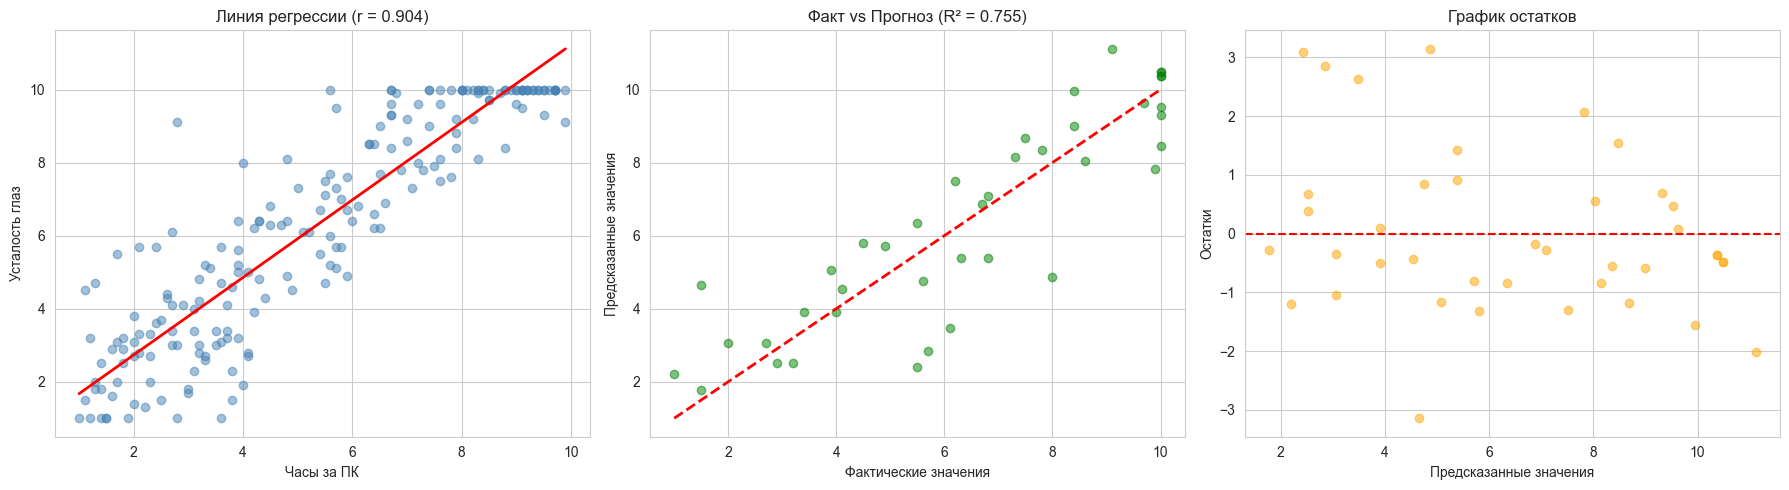


Вывод: Модель показывает хорошую предсказательную способность.
Часы за ПК объясняют 75.5% дисперсии усталости глаз.


In [30]:
# ============================================
# 6. ЛИНЕЙНАЯ РЕГРЕССИЯ
# ============================================
print("\n" + "="*60)
print("6. ЛИНЕЙНАЯ РЕГРЕССИЯ")
print("="*60)

# Выбираем два признака: hours_pc (предиктор) и eye_strain (целевая)
# Корреляция между ними ~0.65 — хорошая линейная связь

corr_value = df['hours_pc'].corr(df['eye_strain'])
print(f"Корреляция между hours_pc и eye_strain: {corr_value:.4f}")

feature_cols = ['hours_pc']
target_col = 'eye_strain'

X = df[feature_cols]
y = df[target_col]

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)

# Прогноз
y_pred = model.predict(X_test)

# Метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nМодель: {target_col} ~ {feature_cols[0]}")
print(f"Уравнение: eye_strain = {model.intercept_:.4f} + ({model.coef_[0]:.4f}) × hours_pc")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: линия регрессии на всех данных
axes[0].scatter(df['hours_pc'], df['eye_strain'], alpha=0.5, c='steelblue')
X_line = np.linspace(df['hours_pc'].min(), df['hours_pc'].max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
axes[0].plot(X_line, y_line, 'r-', lw=2)
axes[0].set_xlabel('Часы за ПК')
axes[0].set_ylabel('Усталость глаз')
axes[0].set_title(f'Линия регрессии (r = {corr_value:.3f})')

# График 2: факт vs прогноз
axes[1].scatter(y_test, y_pred, alpha=0.5, c='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel('Фактические значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].set_title(f'Факт vs Прогноз (R² = {r2:.3f})')

# График 3: остатки
residuals = y_test - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.5, c='orange')
axes[2].axhline(y=0, color='r', linestyle='--')
axes[2].set_xlabel('Предсказанные значения')
axes[2].set_ylabel('Остатки')
axes[2].set_title('График остатков')

plt.tight_layout()
plt.savefig('regression_results.png', dpi=100)
plt.show()

print("\nВывод: Модель показывает хорошую предсказательную способность.")
print(f"Часы за ПК объясняют {r2*100:.1f}% дисперсии усталости глаз.")